**1 - MOUNT DRIVE & IMPORT**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse
import pickle
import os

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from imblearn.over_sampling import SMOTE

Mounted at /content/drive


**2 - LOAD & GABUNG SEMUA HASIL PELABELAN**

In [ ]:
path_anotasi = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_ANOTASI"

df_a1_fase1  = pd.read_csv(f"{path_anotasi}/anotator1_fase1_consensus.csv")
df_a1_fase2  = pd.read_excel(f"{path_anotasi}/anotator1_fase2.xlsx")
df_a2_fase2  = pd.read_excel(f"{path_anotasi}/anotator2_fase2.xlsx")

df_uji           = df_a1_fase1.head(100).copy()
df_a1_fase1_sisa = df_a1_fase1.iloc[100:].copy()

df_all = pd.concat([
    df_uji,
    df_a1_fase1_sisa,
    df_a1_fase2,
    df_a2_fase2
], ignore_index=True)

df_all['text_clean'] = df_all['text_clean'].fillna('').astype(str)

print(f"✅ 100 data uji        : {len(df_uji)}")
print(f"✅ Sisa fase 1         : {len(df_a1_fase1_sisa)}")
print(f"✅ Fase 2 anotator 1   : {len(df_a1_fase2)}")
print(f"✅ Fase 2 anotator 2   : {len(df_a2_fase2)}")
print(f"📊 Total data tergabung: {len(df_all)}")

✅ 100 data uji        : 100
✅ Sisa fase 1         : 760
✅ Fase 2 anotator 1   : 459
✅ Fase 2 anotator 2   : 1220
📊 Total data tergabung: 2539


**3 - VISUALISASI DISTRIBUSI AWAL**

📊 Distribusi Label:
   Non-Sarkasme (0) : 2163
   Sarkasme (1)     : 376
   Belum dilabeli   : 0
   Total            : 2539


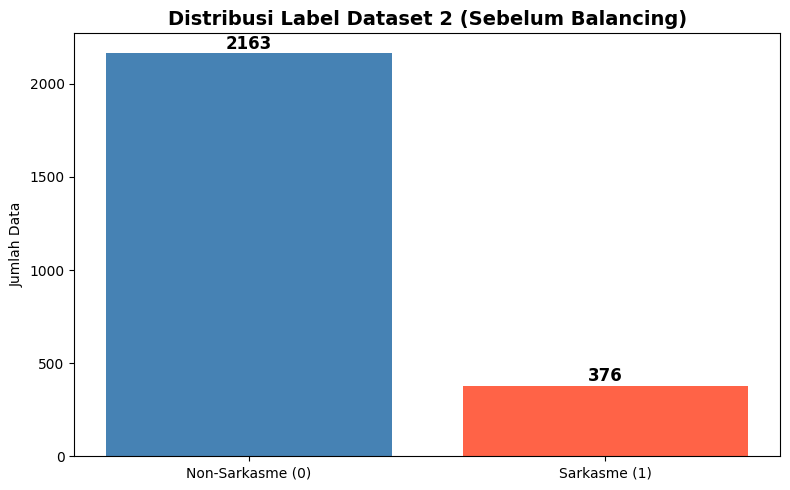

In [ ]:
print("📊 Distribusi Label:")
print(f"   Non-Sarkasme (0) : {(df_all['label'] == 0).sum()}")
print(f"   Sarkasme (1)     : {(df_all['label'] == 1).sum()}")
print(f"   Belum dilabeli   : {df_all['label'].isna().sum()}")
print(f"   Total            : {len(df_all)}")

plt.figure(figsize=(8, 5))
label_counts = df_all['label'].value_counts().sort_index()
bars = plt.bar(['Non-Sarkasme (0)', 'Sarkasme (1)'],
               label_counts.values,
               color=['steelblue', 'tomato'])

for bar, val in zip(bars, label_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.title('Distribusi Label Dataset 2 (Sebelum Balancing)', fontsize=14, fontweight='bold')
plt.ylabel('Jumlah Data')
plt.tight_layout()
plt.show()

**4 - SPLITTING DATA (70:10:20)**

In [ ]:
X = df_all['text_clean']
y = df_all['label']

# Split pertama: 80% train+val, 20% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Split kedua: 70% train, 10% val dari 80% tadi
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.125,  # 10% dari total = 12.5% dari 80%
    random_state=42,
    stratify=y_temp
)

print(f"✅ Splitting Data (70:10:20):")
print(f"   Train      : {len(X_train)} data ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Validasi   : {len(X_val)} data ({len(X_val)/len(X)*100:.1f}%)")
print(f"   Test       : {len(X_test)} data ({len(X_test)/len(X)*100:.1f}%)")
print(f"   Total      : {len(X_train)+len(X_val)+len(X_test)} data")

✅ Splitting Data (70:10:20):
   Train      : 1777 data (70.0%)
   Validasi   : 254 data (10.0%)
   Test       : 508 data (20.0%)
   Total      : 2539 data


**5 - VISUALISASI DISTRIBUSI PER SUBSET**

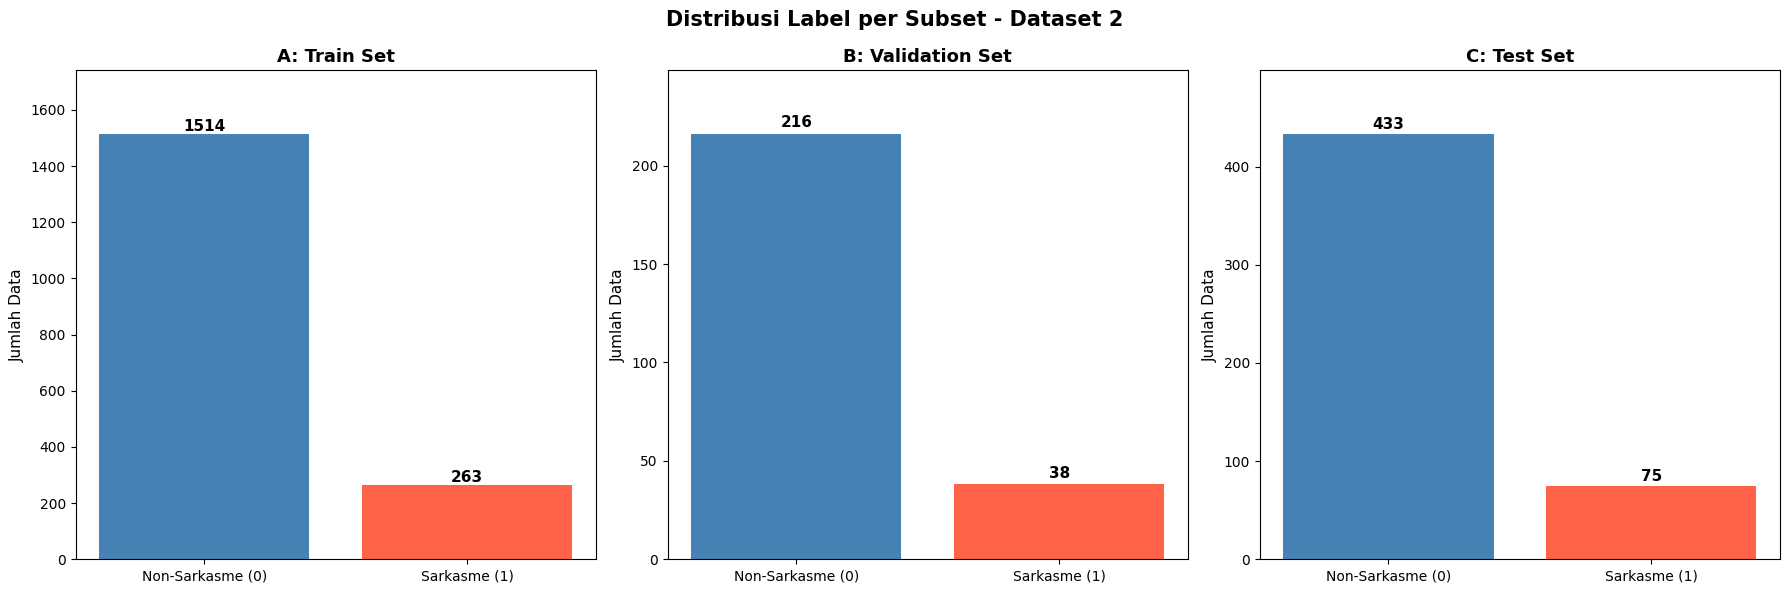

✅ Bar chart berhasil disimpan!


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

datasets = {
    'A: Train Set': y_train.value_counts().sort_index(),
    'B: Validation Set': y_val.value_counts().sort_index(),
    'C: Test Set': y_test.value_counts().sort_index()
}

colors = ['steelblue', 'tomato']
labels = ['Non-Sarkasme (0)', 'Sarkasme (1)']

for ax, (title, counts) in zip(axes, datasets.items()):
    bars = ax.bar(labels, counts.values, color=colors)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah Data', fontsize=11)
    ax.set_ylim(0, max(counts.values) * 1.15)

plt.suptitle('Distribusi Label per Subset - Dataset 2', fontsize=15, fontweight='bold')
plt.tight_layout()

save_path = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_SPLITTING"
os.makedirs(save_path, exist_ok=True)
plt.savefig(f"{save_path}/distribusi_per_dataset.png", dpi=300)
plt.show()
print("✅ Bar chart berhasil disimpan!")

**6 - Tahap 1: TF-IDF**

In [ ]:
print("📍 TAHAP 1: TF-IDF Vectorization")
print("-" * 60)

# Buat dataframe train
df_train = pd.DataFrame({'text_clean': X_train, 'label': y_train})

# TF-IDF di-fit HANYA di data train
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train_tfidf = vectorizer.fit_transform(df_train['text_clean'])
y_train_ori   = df_train['label'].values

print(f"✅ TF-IDF selesai")
print(f"   Shape  : {X_train_tfidf.shape}")
print(f"   Format : sparse matrix")

# ============================
# Simpan TF-IDF sebelum SMOTE
# ============================

scipy.sparse.save_npz(
    f"{save_path}/X_train_tfidf.npz",
    X_train_tfidf
)

np.save(
    f"{save_path}/y_train.npy",
    y_train_ori
)

print("✅ X_train sebelum SMOTE disimpan")
print(X_train_tfidf.shape)

📍 TAHAP 1: TF-IDF Vectorization
------------------------------------------------------------
✅ TF-IDF selesai
   Shape  : (1777, 5000)
   Format : sparse matrix
✅ X_train sebelum SMOTE disimpan
(1777, 5000)


**7 - Tahap 2: SMOTE**

In [ ]:
print("📍 TAHAP 2: SMOTE Oversampling")
print("-" * 60)

print(f"\n🟡 Distribusi sebelum SMOTE:")
print(f"   Non-Sarkasme (0) : {(y_train_ori==0).sum()}")
print(f"   Sarkasme (1)     : {(y_train_ori==1).sum()}")
print(f"   Rasio            : 1 : {(y_train_ori==0).sum()/(y_train_ori==1).sum():.2f}")

smote = SMOTE(
    sampling_strategy=1.0,
    random_state=42,
    k_neighbors=5
)

X_train_final, y_train_final = smote.fit_resample(X_train_tfidf, y_train_ori)

print(f"\n🟢 SETELAH SMOTE (rasio 1:1):")
print(f"   Non-Sarkasme (0) : {(y_train_final==0).sum()}")
print(f"   Sarkasme (1)     : {(y_train_final==1).sum()}")
print(f"   Data ditambah    : {len(y_train_final) - len(y_train_ori)}")
print(f"   Total train      : {len(y_train_final)}")
print(f"   Format           : sparse matrix {X_train_final.shape}")

📍 TAHAP 2: SMOTE Oversampling
------------------------------------------------------------

🟡 Distribusi sebelum SMOTE:
   Non-Sarkasme (0) : 1514
   Sarkasme (1)     : 263
   Rasio            : 1 : 5.76

🟢 SETELAH SMOTE (rasio 1:1):
   Non-Sarkasme (0) : 1514
   Sarkasme (1)     : 1514
   Data ditambah    : 1251
   Total train      : 3028
   Format           : sparse matrix (3028, 5000)


**8 - TRANSFORM VAL&TEST**

In [ ]:
print("📍 TAHAP 3: Transform Val & Test")
print("-" * 60)

# Hanya transform, TIDAK fit ulang
X_val_tfidf  = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print(f"✅ Val  : {X_val_tfidf.shape}")
print(f"✅ Test : {X_test_tfidf.shape}")
print(f"\n⚠️  Val & Test tidak di-resample (tetap original)")
print(f"   Val  | Non-Sarkasme: {(y_val==0).sum()} | Sarkasme: {(y_val==1).sum()}")
print(f"   Test | Non-Sarkasme: {(y_test==0).sum()} | Sarkasme: {(y_test==1).sum()}")

📍 TAHAP 3: Transform Val & Test
------------------------------------------------------------
✅ Val  : (254, 5000)
✅ Test : (508, 5000)

⚠️  Val & Test tidak di-resample (tetap original)
   Val  | Non-Sarkasme: 216 | Sarkasme: 38
   Test | Non-Sarkasme: 433 | Sarkasme: 75


**9 - VISUALISASI SEBELUM & SESUDAH SMOTE**

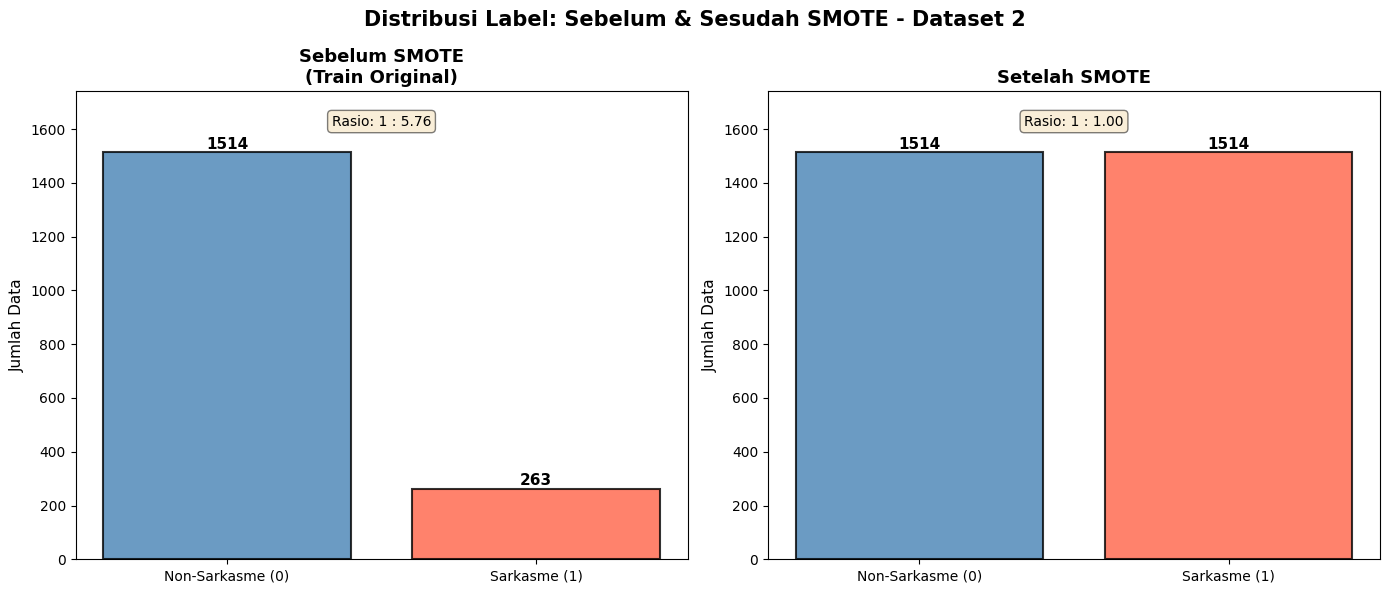

✅ Grafik berhasil disimpan!


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

data_viz = {
    'Sebelum SMOTE\n(Train Original)' : pd.Series(y_train_ori).value_counts().sort_index(),
    'Setelah SMOTE'      : pd.Series(y_train_final).value_counts().sort_index()
}

colors = ['steelblue', 'tomato']
labels = ['Non-Sarkasme (0)', 'Sarkasme (1)']

for ax, (title, counts) in zip(axes, data_viz.items()):
    bars = ax.bar(labels, counts.values, color=colors,  alpha=0.8, edgecolor='black', linewidth=1.5)

    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                str(val), ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Jumlah Data', fontsize=11)
    ax.set_ylim(0, max(counts.values) * 1.15)

    if len(counts) == 2:
        ratio = counts.iloc[0] / counts.iloc[1]
        ax.text(0.5, 0.95, f'Rasio: 1 : {ratio:.2f}',
                transform=ax.transAxes, fontsize=10,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
                ha='center', va='top')

plt.suptitle('Distribusi Label: Sebelum & Sesudah SMOTE - Dataset 2', fontsize=15, fontweight='bold')
plt.tight_layout()

save_path = "/content/drive/MyDrive/SKRIPSI/CODE/HASIL_SPLITTING"
os.makedirs(save_path, exist_ok=True)
plt.savefig(f"{save_path}/proses_balancing_train.png", dpi=300)
plt.show()
print("✅ Grafik berhasil disimpan!")

**10 - SIMPAN SEMUA FILE**

In [ ]:
print("📍 TAHAP 4: Menyimpan Semua File")
print("-" * 60)

# ── SVM: sparse matrix ──────────────────────────────────────
scipy.sparse.save_npz(f"{save_path}/X_train_final.npz",  X_train_final)
scipy.sparse.save_npz(f"{save_path}/X_val_tfidf.npz",    X_val_tfidf)
scipy.sparse.save_npz(f"{save_path}/X_test_tfidf.npz",   X_test_tfidf)
np.save(f"{save_path}/y_train_final.npy", y_train_final)
np.save(f"{save_path}/y_val.npy",         y_val.values)
np.save(f"{save_path}/y_test.npy",        y_test.values)

# ── TF-IDF vectorizer ────────────────────────────────────────
with open(f"{save_path}/tfidf_vectorizer.pkl", 'wb') as f:
    pickle.dump(vectorizer, f)

# ── IndoBERT: teks asli ──────────────────────────────────────
val_df  = pd.DataFrame({'text_clean': X_val,  'label': y_val})
test_df = pd.DataFrame({'text_clean': X_test, 'label': y_test})

df_train.to_csv(f"{save_path}/data_train.csv",  index=False)
val_df.to_csv(f"{save_path}/data_val.csv",      index=False)
test_df.to_csv(f"{save_path}/data_test.csv",    index=False)

print(f"\n✅ Semua file berhasil disimpan ke:")
print(f"   {save_path}")
print(f"\n📦 File untuk SVM:")
print(f"   X_train_final.npz → {X_train_final.shape[0]} data (SMOTE)")
print(f"   X_val_tfidf.npz   → {X_val_tfidf.shape[0]} data")
print(f"   X_test_tfidf.npz  → {X_test_tfidf.shape[0]} data")
print(f"   y_train_final.npy → {len(y_train_final)} label")
print(f"   y_val.npy         → {len(y_val)} label")
print(f"   y_test.npy        → {len(y_test)} label")
print(f"   tfidf_vectorizer.pkl")
print(f"\n📦 File untuk IndoBERT:")
print(f"   data_train.csv → {len(df_train)} data (teks original)")
print(f"   data_val.csv   → {len(val_df)} data")
print(f"   data_test.csv  → {len(test_df)} data")

📍 TAHAP 4: Menyimpan Semua File
------------------------------------------------------------

✅ Semua file berhasil disimpan ke:
   /content/drive/MyDrive/SKRIPSI/CODE/HASIL_SPLITTING

📦 File untuk SVM:
   X_train_final.npz → 3028 data (SMOTE)
   X_val_tfidf.npz   → 254 data
   X_test_tfidf.npz  → 508 data
   y_train_final.npy → 3028 label
   y_val.npy         → 254 label
   y_test.npy        → 508 label
   tfidf_vectorizer.pkl

📦 File untuk IndoBERT:
   data_train.csv → 1777 data (teks original)
   data_val.csv   → 254 data
   data_test.csv  → 508 data
